In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches



In [2]:
output_folder=("../PhysiCell/results/fixed_cell_cycle/cell_volumes.csv")
pc_df = pd.read_csv(output_folder,float_precision='round_trip').sort_values(by=['dt']).reset_index(drop=True)

In [3]:
output_folder=("../Biodynamo/unit_test_cellcycle/new_results/cell-0-sim1.csv")
bd_df = pd.read_csv(output_folder,header=None)
bd_df.columns = ['timestep', 'volume', 'Phase', 'Age']
bd_df['vol']= bd_df['volume']/bd_df['volume'][0]
bd_df

,timestep,volume,Phase,Age,vol
0,0.01,523.599,1,1,1.000000
1,0.02,523.599,1,2,1.000000
2,0.03,523.599,1,3,1.000000
3,0.04,523.599,1,4,1.000000
4,0.05,523.599,1,5,1.000000
...,...,...,...,...,...
4795,47.96,902.986,2,4796,1.724575
4796,47.97,903.506,2,4797,1.725569
4797,47.98,904.026,2,4798,1.726562
4798,47.99,904.545,2,4799,1.727553


In [4]:
output_folder=("../Chaste/unit_test_cellcycle/results/cellcycle_fixed.dat")
ch_df = pd.DataFrame(columns=["dt","id","x","y","z","g1_duration","s_duration","g2_duration","m_duration","current_phase","target_area","volume"])
with open(output_folder, "r") as f:
    for line in f.read().splitlines():
        data = line.split()
        data = [float(x) if x.replace('.', '', 1).isdigit() else x for x in data]
        dt = data[0]
        for i in range(0,len(data)//11):
            row = {'dt': dt, 'id': data[1+11*i], 'x': data[2+11*i], 'y': data[3+11*i], 'z': data[4+11*i], 'g1_duration': data[5+11*i], 's_duration': data[6+11*i], 'g2_duration': data[7+11*i], 'm_duration': data[8+11*i], 'current_phase': data[9+11*i], 'target_area': data[10+11*i], 'volume': data[11+11*i]}
            row = pd.Series(row)
            df2 = pd.DataFrame(row).transpose()

            ch_df =pd.concat([ch_df,df2],ignore_index=True)
ch_df

,dt,id,x,y,z,g1_duration,s_duration,g2_duration,m_duration,current_phase,target_area,volume
0,0.0,0.0,0.0,0.0,0.1,7.0,6.0,3.0,2.0,G1,0.523599,0.523599
1,0.1,0.0,0.0,0.0,3.0,7.0,6.0,3.0,2.0,G1,0.523599,0.523599
2,0.2,0.0,0.0,0.0,3.0,7.0,6.0,3.0,2.0,G1,0.523599,0.523599
3,0.3,0.0,0.0,0.0,3.0,7.0,6.0,3.0,2.0,G1,0.523599,0.523599
4,0.4,0.0,0.0,0.0,3.0,7.0,6.0,3.0,2.0,G1,0.523599,0.523599
...,...,...,...,...,...,...,...,...,...,...,...,...
1016,47.9,3.0,-0.963926,-0.588464,2.77931,7.0,6.0,3.0,2.0,S,0.871807,0.870852
1017,48.0,0.0,0.826793,0.787988,2.77407,7.0,6.0,3.0,2.0,S,0.877028,0.876112
1018,48.0,1.0,-0.29871,0.37595,2.96132,7.0,6.0,3.0,2.0,S,0.877028,0.876041
1019,48.0,2.0,0.620875,-0.372871,2.91127,7.0,6.0,3.0,2.0,S,0.877028,0.876065


In [5]:
file = "../Tisim/unit_test_cellcycle/cell cycle fix.csv"
data = pd.read_csv(file, header=0)
time_steps = data['time (hour)']
volume_columns = data.columns[1:]  # Assuming all other columns are cell volumes

average_volumes = data[volume_columns].mean(axis=1, skipna=True)
initial_total_volume = average_volumes.iloc[0]

percentage_total_volumes = (average_volumes / initial_total_volume)*100
# print(percentage_total_volumes)
# Create a new DataFrame with time steps and percentage of total volumes
ts_df = pd.DataFrame({
    'timestep': time_steps,
    'volumes': percentage_total_volumes
})
ts_df

,timestep,volumes
0,1,100.000
1,2,100.000
2,3,100.000
3,4,100.000
4,5,100.000
5,6,100.000
6,7,119.558
7,8,138.407
8,9,154.093
9,10,167.035


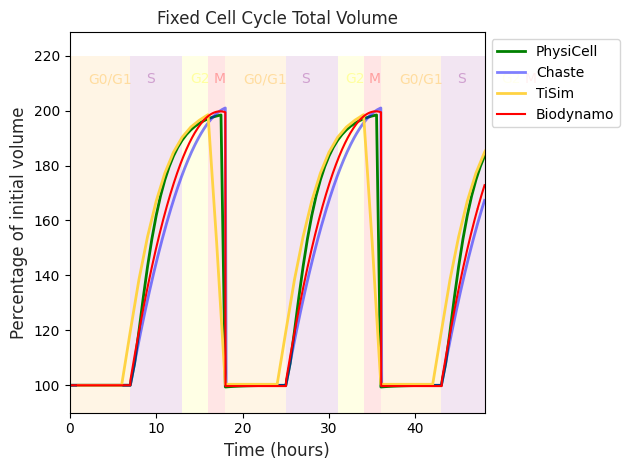

In [6]:
fig, ax = plt.subplots()

# Normalize time to hours
pc_df['dt'] = pc_df['dt'] / 60
pc_init_vol = pc_df.iloc[0]["total_volume"]

# Compute average volume per time step (normalized)
pc_avg_vol = pc_df.groupby('dt')['total_volume'].mean()
pc_dts = pc_avg_vol.index
pc_vols = (pc_avg_vol / pc_init_vol * 100).tolist()

# Plot PhysiCell
ax.plot(pc_dts, pc_vols, label="PhysiCell", color='green', linewidth=2)

# Chaste
ch_init_vol = ch_df.loc[0, "volume"]
ch_avg_vol = ch_df.groupby('dt')['volume'].mean()
dts = ch_avg_vol.index
vols = (ch_avg_vol / ch_init_vol * 100).tolist()
ax.plot(dts, vols, label="Chaste", color='blue', linewidth=2, alpha=0.5)

# TiSim
ax.plot(ts_df['timestep'], ts_df['volumes'], label="TiSim", color='#ffd343', linewidth=2)

# BioDynaMo
ax.plot(bd_df['timestep'], bd_df["vol"] * 100, label="Biodynamo", color="red")

# Add phase background rectangles (G0/G1, S, G2, M)
for i in range(3):  # repeat 3 cell cycles
    base = 18 * i
    phases = [
        (base, 7, 'orange', 'G0/G1'),
        (base + 7, 6, 'purple', 'S'),
        (base + 13, 3, 'yellow', 'G2'),
        (base + 16, 2, 'red', 'M'),
    ]
    for x, w, color, label in phases:
        ax.add_patch(patches.Rectangle((x, 50), w, 170, facecolor=color, alpha=0.1, edgecolor=None))
        if label in ['G2', 'M']:
            ax.text(x + w * 0.3, 210, label, color=color, alpha=0.3)
        else:
            ax.text(x + w * 0.3, 210, label, color=color, alpha=0.3)

# Final plot formatting
ax.set_xlim(0, 48)
ax.set_ylim(90)
ax.set_xlabel("Time (hours)", fontsize=12, color='#262626')
ax.set_ylabel("Percentage of initial volume", fontsize=12, color='#262626')
ax.set_title('Fixed Cell Cycle Total Volume', color='#262626')
ax.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')
plt.tight_layout()
plt.savefig("fixed_cell_cycle_volumes.png", dpi=200)
plt.show()